In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

In [3]:
# data import 
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# pre prcoess the data
# remove the deck column
df.drop('deck', axis=1, inplace=True)

In [5]:
# impute missing values
df['age'] = df['age'].fillna(df['age'].mean())
df['fare'] = df['fare'].fillna(df['fare'].median())
# impute missing values in embark and embarked town
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [6]:
# encode the categorical variables using loop
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'categorical':
        df[col] = LabelEncoder().fit_transform(df[col])
        

In [7]:
# Select features
X = df[['pclass', 'sex', 'age', 'fare', 'embarked']]

# Target
y = df['survived']

# Fill missing values
X['age'] = X['age'].fillna(X['age'].mean())

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

C:\Users\2005a\AppData\Local\Temp\ipykernel_20664\404538661.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['age'] = X['age'].fillna(X['age'].mean())


In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,First,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,Third,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,First,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,Third,1,True,2,0,True


In [9]:
# model call
model = LogisticRegression()

In [10]:
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
# predict the value
y_pred = model.predict(X_test)

In [14]:
# evaluate the model
print('Accuracy_Score : ', accuracy_score(y_test,y_pred))
print('Recall_Score : ', recall_score(y_test,y_pred))
print('Precision_Score : ', precision_score(y_test,y_pred))
print('F1_Score : ', f1_score(y_test,y_pred))
print('Confusion Matrix : \n', confusion_matrix(y_test,y_pred))
print('Classification Report :\n ', classification_report(y_test,y_pred))

Accuracy_Score :  0.7988826815642458
Recall_Score :  0.7432432432432432
Precision_Score :  0.7638888888888888
F1_Score :  0.7534246575342466
Confusion Matrix : 
 [[88 17]
 [19 55]]
Classification Report :
                precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



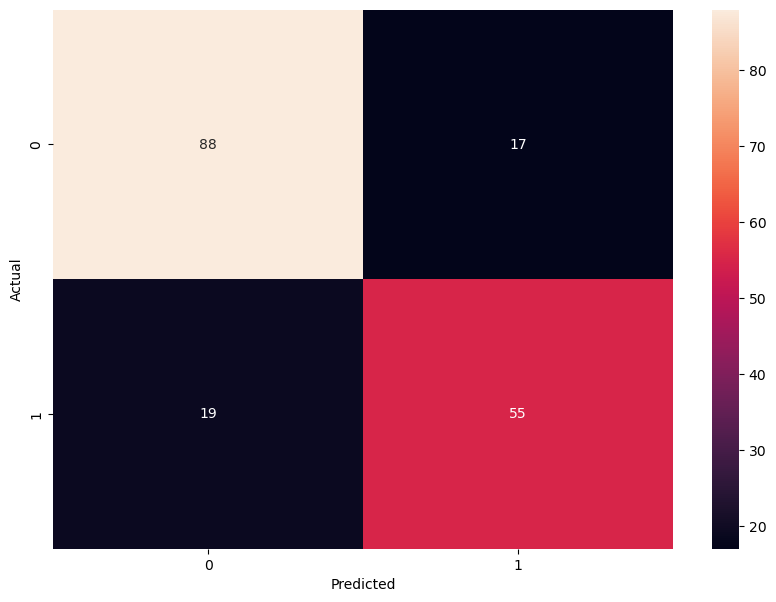

In [17]:
# plot the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix
plt.figure(figsize=(10,7))

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [19]:
# save the model
import pickle

pickle.dump(model, open('LogisticRegression.pkl', 'wb'))